🌱 CORPORATE CARBON CALCULATOR & VISUALIZER
Enter your annual activity data below to generate your impact report.

1. Natural Gas usage (kWh): 50000
2. Fleet Diesel usage (Liters): 1000
3. Refrigerant leakage/top-up (kg of R410A): 3
4. Purchased Electricity (kWh): 10000
5. % of Electricity from Renewable Sources (0-100): 50

------------------------------
📊 CLIMATE IMPACT SUMMARY
------------------------------
Scope 1 Total:           17.88 tCO2e
Scope 2 (Loc-Based):      7.10 tCO2e
Scope 2 (Mkt-Based):      3.55 tCO2e
GRAND TOTAL (Mkt):       21.43 tCO2e
------------------------------


/tmp/ipykernel_13976/203116841.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Source", y="Emissions_tCO2e", data=plot_df, palette="viridis", ax=ax1)


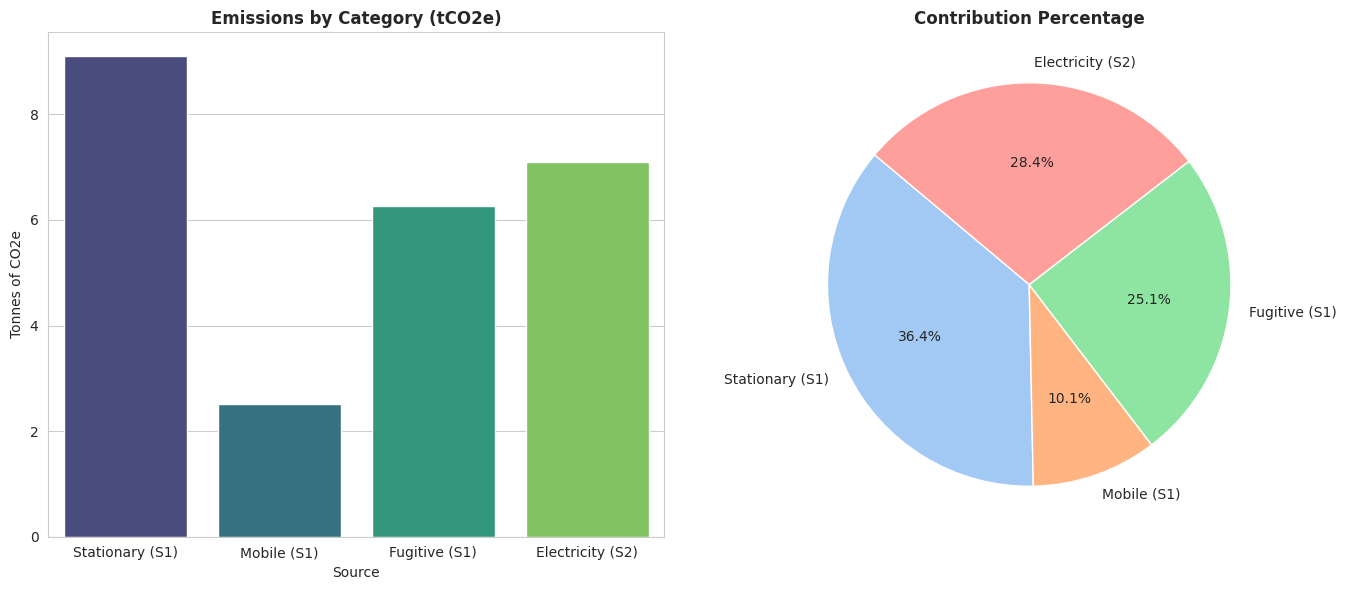

In [2]:
# --- SUSTAINABILITY ANALYST TOOLKIT: SCOPE 1 & 2 CALCULATOR ---
# Created for: Career Portfolio Project
# Standard: GHG Protocol Corporate Standard

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def run_sustainability_suite():
    print("="*50)
    print("🌱 CORPORATE CARBON CALCULATOR & VISUALIZER")
    print("="*50)
    print("Enter your annual activity data below to generate your impact report.\n")

    # --- 1. USER INPUT SECTION ---
    try:
        # Scope 1
        gas_kwh = float(input("1. Natural Gas usage (kWh): ") or 0)
        diesel_litres = float(input("2. Fleet Diesel usage (Liters): ") or 0)
        refrigerant_kg = float(input("3. Refrigerant leakage/top-up (kg of R410A): ") or 0)

        # Scope 2
        elec_kwh = float(input("4. Purchased Electricity (kWh): ") or 0)
        green_pct = float(input("5. % of Electricity from Renewable Sources (0-100): ") or 0)
    except ValueError:
        print("\n❌ Error: Please enter numerical values only.")
        return

    # --- 2. EMISSION FACTORS (2024/25 Benchmarks) ---
    # kg CO2e per unit
    EF_GAS = 0.182
    EF_DIESEL = 2.512
    EF_R410A = 2088    # GWP for R410A
    EF_GRID = 0.71     # Regional Grid Factor (e.g., India Avg)

    # --- 3. CALCULATIONS ---
    # Scope 1
    s1_stat = (gas_kwh * EF_GAS) / 1000
    s1_mob = (diesel_litres * EF_DIESEL) / 1000
    s1_fug = (refrigerant_kg * EF_R410A) / 1000
    total_s1 = s1_stat + s1_mob + s1_fug

    # Scope 2 (Dual Reporting)
    s2_loc = (elec_kwh * EF_GRID) / 1000
    s2_mkt = (elec_kwh * (1 - (green_pct/100)) * EF_GRID) / 1000

    # --- 4. DATA PREPARATION FOR VISUALS ---
    report_data = {
        "Source": ["Stationary (S1)", "Mobile (S1)", "Fugitive (S1)", "Electricity (S2)"],
        "Emissions_tCO2e": [s1_stat, s1_mob, s1_fug, s2_loc]
    }
    df = pd.DataFrame(report_data)

    # --- 5. OUTPUT SUMMARY REPORT ---
    print("\n" + "-"*30)
    print("📊 CLIMATE IMPACT SUMMARY")
    print("-"*30)
    print(f"Scope 1 Total:        {total_s1:>8.2f} tCO2e")
    print(f"Scope 2 (Loc-Based):  {s2_loc:>8.2f} tCO2e")
    print(f"Scope 2 (Mkt-Based):  {s2_mkt:>8.2f} tCO2e")
    print(f"GRAND TOTAL (Mkt):    {(total_s1 + s2_mkt):>8.2f} tCO2e")
    print("-"*30)

    # --- 6. VISUALIZATION ---
    # Filter out zeros to keep the chart clean
    plot_df = df[df['Emissions_tCO2e'] > 0]

    if plot_df.empty:
        print("No emissions data to visualize.")
    else:
        # Create a professional layout
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        sns.set_style("whitegrid")

        # Chart 1: Bar Chart of Totals
        sns.barplot(x="Source", y="Emissions_tCO2e", data=plot_df, palette="viridis", ax=ax1)
        ax1.set_title("Emissions by Category (tCO2e)", fontweight='bold')
        ax1.set_ylabel("Tonnes of CO2e")

        # Chart 2: Pie Chart of Breakdown
        colors = sns.color_palette("pastel")
        ax2.pie(plot_df['Emissions_tCO2e'], labels=plot_df['Source'], autopct='%1.1f%%',
                startangle=140, colors=colors, wedgeprops={'edgecolor': 'white'})
        ax2.set_title("Contribution Percentage", fontweight='bold')

        plt.tight_layout()
        plt.show()

# Execute the tool
run_sustainability_suite()